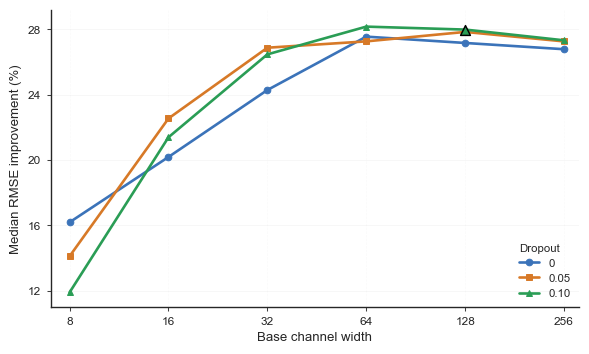

Saved main channel-sweep figure to AMS LaTeX Package V6.1/figures/fig3.png


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from pathlib import Path

# --------------------------
# 1. Config
# --------------------------
base_dir = Path("/Users/ewellmeyer/Documents/research/weights")

# Select which channel counts to include
channels = [8, 16, 32, 64, 128, 256]

# gn_groups used per channel during training (all 1 by default for unet6R runs)
gn_per_ch = {ch: 1 for ch in channels}

# Fixed training parameters (must match what train_pr_dpdk.py used)
k_size    = 3
num_bins  = 64
dP_min    = -700
dP_max    = 1200

def ens_dir(ch, suffix=""):
    gn = gn_per_ch[ch]
    name = (
        f"unet_ens_HG789_PR_dPdK_Softmax_unet6R_ch{ch}_k{k_size}_"
        f"128x_dPbins{num_bins}_gn{gn}_dpmin{dP_min}_dPmax{dP_max}_sigma0.6"
        f"{suffix}"
    )
    return base_dir / name

# --------------------------
# 2. Load results
# --------------------------
def load_pct(suffix=""):
    out = []
    for ch in channels:
        npz_path = ens_dir(ch, suffix) / "softmax_ensemble_analysis_arrays.npz"
        try:
            d = np.load(npz_path)
            idx = d['test_indices']
            rmse_model    = d['rmse_softmax_mean'][idx]
            rmse_baseline = d['rmse_ppe'][idx]
            pct = (rmse_baseline - rmse_model) / rmse_baseline * 100
            out.append(np.median(pct))
        except FileNotFoundError:
            out.append(np.nan)
            print(f"Missing results for ch={ch} (suffix='{suffix}'): {npz_path}")
    return out

pct_improvement     = load_pct("")
pct_improvement_dr  = load_pct("_dr0.05")
pct_improvement_dr1 = load_pct("_dr0.1")

# --------------------------
# 3. Main manuscript plot
# --------------------------
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.size": 8.5,
    "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8.2,
    "legend.title_fontsize": 8.2,
})

fig, ax = plt.subplots(figsize=(5.8, 3.45))

c_soft = "#3B73B9"
c_dr   = "#D77927"
c_dr1  = "#2A9D55"
line_specs = [
    (pct_improvement,     c_soft, "o", "0"),
    (pct_improvement_dr,  c_dr,   "s", "0.05"),
    (pct_improvement_dr1, c_dr1,  "^", "0.10"),
]

for values, color, marker, label in line_specs:
    ax.plot(
        channels, values,
        color=color, marker=marker, label=label,
        linewidth=1.9, markersize=4.8, markeredgewidth=0.7,
        solid_capstyle="round", zorder=3,
    )

# Mark the adopted configuration; the caption explains the black outline.
adopted_ch = 128
adopted_y = pct_improvement_dr1[channels.index(adopted_ch)]
ax.scatter(
    [adopted_ch], [adopted_y],
    s=50, marker="^", facecolor=c_dr1, edgecolor="black",
    linewidth=1.05, zorder=5,
)

ax.set_xscale("log", base=2)
ax.set_xticks(channels)
ax.set_xticklabels([str(ch) for ch in channels])
ax.set_xlim(7, 285)
ax.set_ylim(11.0, 29.2)
ax.set_yticks([12, 16, 20, 24, 28])
ax.set_xlabel("Base channel width")
ax.set_ylabel("Median RMSE improvement (%)")

ax.grid(True, axis="y", linestyle="-", linewidth=0.55, alpha=0.20)
ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.10)
ax.tick_params(axis="both", length=3.2, width=0.75, color="0.25")
sns.despine(ax=ax)

legend = ax.legend(
    title="Dropout", frameon=False, loc="lower right",
    handlelength=1.8, borderaxespad=0.35, labelspacing=0.45,
)
legend._legend_box.align = "left"

fig.tight_layout(pad=0.45)
fig_path = Path("AMS LaTeX Package V6.1/figures/fig3.png")
fig_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_path, dpi=350, bbox_inches="tight")
plt.show()
print(f"Saved main channel-sweep figure to {fig_path}")



Fig. 3 dropout=0.1 seed diagnostics for channels [8, 16, 32, 64, 128, 256]

8 channels
  retained seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] (10/10); excluded: []
  ensemble median improvement: global=11.90%, land=9.95%
  retained seed median improvement: mean=9.04%, std=0.96%, IQR=0.97%, range=3.48%
  in-range improvement: global=11.98%, land=11.84%
  high-baseline-error median improvement: global=10.74%

16 channels
  retained seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] (10/10); excluded: []
  ensemble median improvement: global=21.39%, land=18.57%
  retained seed median improvement: mean=18.63%, std=0.45%, IQR=0.53%, range=1.37%
  in-range improvement: global=20.44%, land=19.73%
  high-baseline-error median improvement: global=21.32%

32 channels
  retained seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] (10/10); excluded: []
  ensemble median improvement: global=26.46%, land=24.91%
  retained seed median improvement: mean=23.79%, std=0.21%, IQR=0.19%, range=0.71%
  in-range improvement: global=25.60%, 

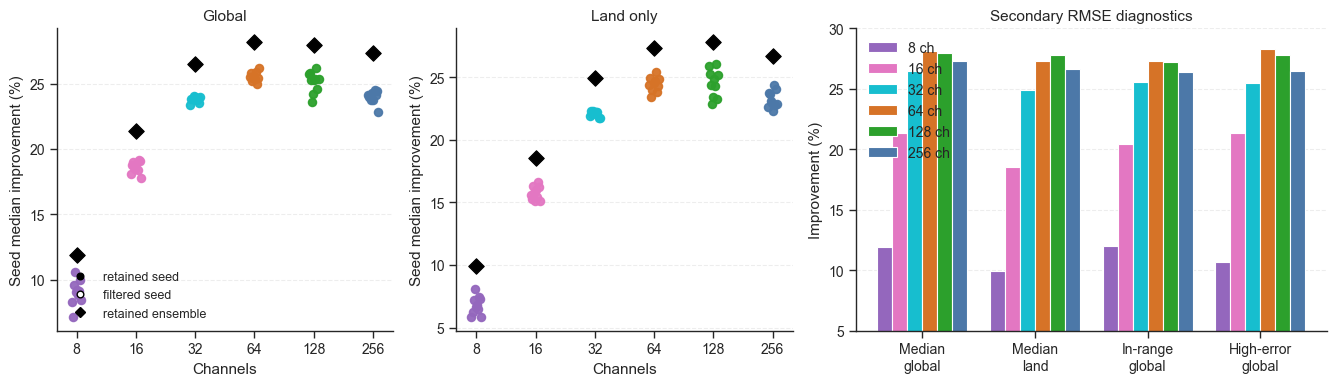


Saved diagnostic figure to AMS LaTeX Package V6.1/figures/channel_sweep_seed_diagnostics.png
Decision: keep Fig. 3 simple. No larger checked channel count has larger retained-seed spread or materially better checked RMSE diagnostics than 128 channels.
Note: calibration, NLL/CRPS, and spatial-smoothness comparisons are not in these saved channel-sweep arrays. Computing them for these channel counts would require rerunning probabilistic inference or extending post-analysis outputs; the available diagnostics do not support doing that just for Fig. 3.


In [23]:
# Fig. 3 seed-level diagnostics: selected channel counts
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Focus on the final dropout setting used for the manuscript model.
# Add/remove channel counts here; the plotting code below derives positions dynamically.
# Colors are defined for all known channel counts, even if only a subset is plotted.
all_possible_channels = [1, 2, 4, 8, 16, 32, 64, 128, 192, 200, 256, 400]
diag_channels = [8, 16, 32, 64, 128, 256]
diag_suffix = "_dr0.1"
diag_out = Path("AMS LaTeX Package V6.1/figures/channel_sweep_seed_diagnostics.png")


def pct_improve(baseline_rmse, model_rmse):
    baseline_rmse = np.asarray(baseline_rmse, dtype=float)
    model_rmse = np.asarray(model_rmse, dtype=float)
    return (1.0 - model_rmse / (baseline_rmse + 1e-12)) * 100.0


def load_seed_diagnostics(ch, suffix=diag_suffix):
    run_dir = ens_dir(ch, suffix)
    arr_path = run_dir / "softmax_ensemble_analysis_arrays.npz"
    json_path = run_dir / "softmax_ensemble_analysis_results.json"
    arr = np.load(arr_path)
    meta = json.loads(json_path.read_text()) if json_path.exists() else {}

    idx = arr["test_indices"]
    good = arr["good_members"].astype(int)
    n_seed = arr["rmse_softmax_members"].shape[0]
    all_seed = np.arange(n_seed)
    excluded = np.setdiff1d(all_seed, good)

    ppe = arr["rmse_ppe"][idx]
    ppe_land = arr["rmse_ppe_land"][idx]
    ens = arr["rmse_softmax_mean"][idx]
    ens_land = arr["rmse_softmax_mean_land"][idx]
    members = arr["rmse_softmax_members"][:, idx]
    members_land = arr["rmse_softmax_members_land"][:, idx]

    seed_imp = np.nanmedian(pct_improve(ppe[None, :], members), axis=1)
    seed_imp_land = np.nanmedian(pct_improve(ppe_land[None, :], members_land), axis=1)
    seed_mean_rmse = np.nanmean(members, axis=1)

    ens_imp = np.nanmedian(pct_improve(ppe, ens))
    ens_imp_land = np.nanmedian(pct_improve(ppe_land, ens_land))

    high_mask = ppe >= np.nanpercentile(ppe, 90)
    ens_imp_high = np.nanmedian(pct_improve(ppe[high_mask], ens[high_mask]))

    range_diag = meta.get("range_diagnostics", {}).get("test", {})
    in_range_global = range_diag.get("global", {}).get("pct_improvement_in_range_only", np.nan)
    in_range_land = range_diag.get("land_only", {}).get("pct_improvement_in_range_only", np.nan)

    return {
        "ch": ch,
        "run_dir": run_dir,
        "good": good,
        "excluded": excluded,
        "n_seed": n_seed,
        "seed_imp": seed_imp,
        "seed_imp_land": seed_imp_land,
        "seed_mean_rmse": seed_mean_rmse,
        "ens_imp": ens_imp,
        "ens_imp_land": ens_imp_land,
        "ens_imp_high": ens_imp_high,
        "in_range_global": float(in_range_global),
        "in_range_land": float(in_range_land),
    }


diag = {ch: load_seed_diagnostics(ch) for ch in diag_channels}

print(f"Fig. 3 dropout=0.1 seed diagnostics for channels {diag_channels}")
for ch, d in diag.items():
    good = d["good"]
    seed_imp = d["seed_imp"]
    print(f"\n{ch} channels")
    print(f"  retained seeds: {good.tolist()} ({len(good)}/{d['n_seed']}); excluded: {d['excluded'].tolist()}")
    print(f"  ensemble median improvement: global={d['ens_imp']:.2f}%, land={d['ens_imp_land']:.2f}%")
    print(
        "  retained seed median improvement: "
        f"mean={np.nanmean(seed_imp[good]):.2f}%, "
        f"std={np.nanstd(seed_imp[good], ddof=1):.2f}%, "
        f"IQR={np.nanpercentile(seed_imp[good], 75) - np.nanpercentile(seed_imp[good], 25):.2f}%, "
        f"range={np.nanmax(seed_imp[good]) - np.nanmin(seed_imp[good]):.2f}%"
    )
    print(f"  in-range improvement: global={d['in_range_global']:.2f}%, land={d['in_range_land']:.2f}%")
    print(f"  high-baseline-error median improvement: global={d['ens_imp_high']:.2f}%")

# Plot seed-level skill and simple secondary diagnostics.
sns.set_context("paper", font_scale=1.15)
sns.set_style("ticks")
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0), gridspec_kw={"width_ratios": [1, 1, 1.4]})

fallback_palette = sns.color_palette("husl", n_colors=len(all_possible_channels)).as_hex()
preferred_colors = {
    1: "#999999",
    2: "#8c564b",
    4: "#7f7f7f",
    8: "#9467bd",
    16: "#e377c2",
    32: "#17becf",
    64: "#d67327",
    128: "#2ca02c",
    192: "#bcbd22",
    200: "#aec7e8",
    256: "#4c78a8",
    400: "#d62728",
}
colors = {
    ch: preferred_colors.get(ch, fallback_palette[i])
    for i, ch in enumerate(all_possible_channels)
}
xpos = {ch: i for i, ch in enumerate(diag_channels)}
xticks = [xpos[ch] for ch in diag_channels]
xticklabels = [str(ch) for ch in diag_channels]

for ax, key, ylabel, title in [
    (axes[0], "seed_imp", "Seed median improvement (%)", "Global"),
    (axes[1], "seed_imp_land", "Seed median improvement (%)", "Land only"),
]:
    for ch, d in diag.items():
        x = xpos[ch]
        y = d[key]
        good = set(d["good"].tolist())
        for i, val in enumerate(y):
            jitter = (i - (len(y) - 1) / 2) * 0.018
            retained = i in good
            ax.scatter(
                x + jitter,
                val,
                s=32,
                facecolor=colors[ch] if retained else "white",
                edgecolor=colors[ch],
                linewidth=1.2,
                alpha=0.95,
                zorder=3,
            )
        ens_key = "ens_imp" if key == "seed_imp" else "ens_imp_land"
        ax.scatter(x, d[ens_key], marker="D", s=62, color="black", zorder=4)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.set_xlabel("Channels")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    sns.despine(ax=ax)

metric_labels = ["Median\nglobal", "Median\nland", "In-range\nglobal", "High-error\nglobal"]
metric_values = {
    ch: [d["ens_imp"], d["ens_imp_land"], d["in_range_global"], d["ens_imp_high"]]
    for ch, d in diag.items()
}
x = np.arange(len(metric_labels))
width = min(0.8 / len(diag_channels), 0.28)
offsets = (np.arange(len(diag_channels)) - (len(diag_channels) - 1) / 2) * width
for offset, ch in zip(offsets, diag_channels):
    axes[2].bar(x + offset, metric_values[ch], width, color=colors[ch], label=f"{ch} ch")
axes[2].set_xticks(x)
axes[2].set_xticklabels(metric_labels)
axes[2].set_ylim(5, 30)
axes[2].set_ylabel("Improvement (%)")
axes[2].set_title("Secondary RMSE diagnostics")
axes[2].grid(axis="y", linestyle="--", alpha=0.35)
axes[2].legend(frameon=False, loc="upper left")
sns.despine(ax=axes[2])

legend_handles = [
    Line2D([0], [0], marker="o", color="black", markerfacecolor="black", linestyle="None", label="retained seed"),
    Line2D([0], [0], marker="o", color="black", markerfacecolor="white", linestyle="None", label="filtered seed"),
    Line2D([0], [0], marker="D", color="black", linestyle="None", label="retained ensemble"),
]
axes[0].legend(handles=legend_handles, frameon=False, fontsize=9, loc="lower left")

plt.tight_layout()
diag_out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(diag_out, dpi=300, bbox_inches="tight")
plt.show()

# Simple decision rule for the manuscript figure.
reference_ch = 128 if 128 in diag else diag_channels[0]
ref_iqr = np.nanpercentile(diag[reference_ch]["seed_imp"][diag[reference_ch]["good"]], 75) - np.nanpercentile(diag[reference_ch]["seed_imp"][diag[reference_ch]["good"]], 25)
flagged = []
for ch in diag_channels:
    # The stability concern is whether larger models justify their extra compute.
    # Smaller models can be noisier without changing the 128-vs-256 decision.
    if ch <= reference_ch:
        continue
    ch_iqr = np.nanpercentile(diag[ch]["seed_imp"][diag[ch]["good"]], 75) - np.nanpercentile(diag[ch]["seed_imp"][diag[ch]["good"]], 25)
    ch_secondary_better = any(np.asarray(metric_values[ch]) > np.asarray(metric_values[reference_ch]) + 0.25)
    if (ch_iqr > ref_iqr) or ch_secondary_better:
        flagged.append(ch)

print(f"\nSaved diagnostic figure to {diag_out}")
if not flagged:
    print(f"Decision: keep Fig. 3 simple. No larger checked channel count has larger retained-seed spread or materially better checked RMSE diagnostics than {reference_ch} channels.")
else:
    print(f"Decision: inspect larger channel count(s) {flagged}; one or more checked diagnostics differs enough to consider a supplemental seed-spread panel.")

print("Note: calibration, NLL/CRPS, and spatial-smoothness comparisons are not in these saved channel-sweep arrays. Computing them for these channel counts would require rerunning probabilistic inference or extending post-analysis outputs; the available diagnostics do not support doing that just for Fig. 3.")


Supplemental channel-sweep seed variability

Dropout 0.00
    8 ch: global=16.19%, land=13.59%, retained=10/10
   16 ch: global=20.18%, land=17.14%, retained=10/10
   32 ch: global=24.28%, land=21.96%, retained=10/10
   64 ch: global=27.55%, land=26.77%, retained=10/10
  128 ch: global=27.16%, land=25.96%, retained=10/10
  256 ch: global=26.78%, land=25.95%, retained=10/10

Dropout 0.05
    8 ch: global=14.11%, land=12.28%, retained=9/10
   16 ch: global=22.54%, land=20.15%, retained=10/10
   32 ch: global=26.87%, land=25.04%, retained=10/10
   64 ch: global=27.26%, land=26.48%, retained=10/10
  128 ch: global=27.84%, land=27.10%, retained=10/10
  256 ch: global=27.26%, land=27.04%, retained=10/10

Dropout 0.10
    8 ch: global=11.90%, land=9.95%, retained=10/10
   16 ch: global=21.39%, land=18.57%, retained=10/10
   32 ch: global=26.46%, land=24.91%, retained=10/10
   64 ch: global=28.16%, land=27.31%, retained=10/10
  128 ch: global=27.98%, land=27.81%, retained=10/10
  256 ch: globa

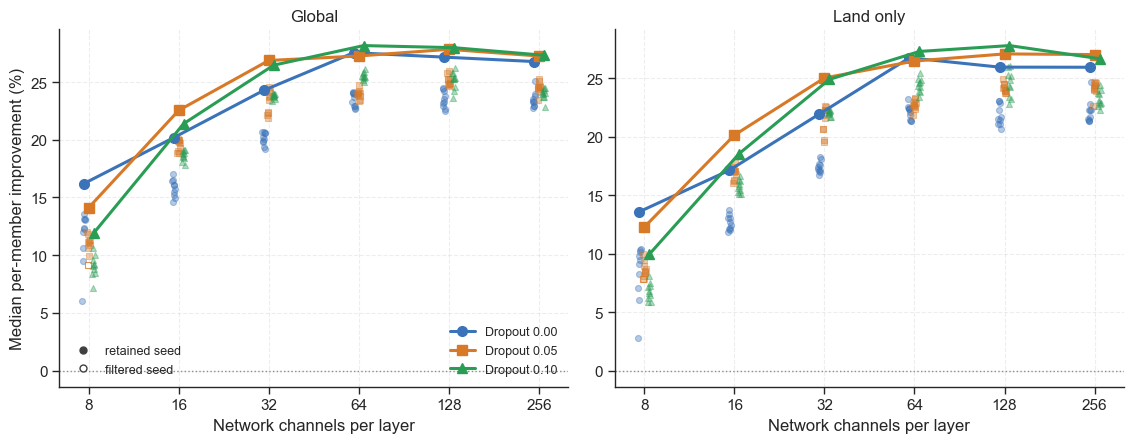

Saved supplemental seed-variability figure to AMS LaTeX Package V6.1/supp_figures/figS4.png


In [24]:
# Supplemental Fig. S4: channel-sweep seed variability across dropout rates
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

supp_sweep_channels = channels
supp_dropout_configs = [
    ("", "Dropout 0.00", c_soft, "o"),
    ("_dr0.05", "Dropout 0.05", c_dr, "s"),
    ("_dr0.1", "Dropout 0.10", c_dr1, "^"),
]
supp_out = Path("AMS LaTeX Package V6.1/supp_figures/figS4.png")


def pct_improve(baseline_rmse, model_rmse):
    baseline_rmse = np.asarray(baseline_rmse, dtype=float)
    model_rmse = np.asarray(model_rmse, dtype=float)
    return (1.0 - model_rmse / (baseline_rmse + 1e-12)) * 100.0


def load_channel_seed_sweep(ch, suffix):
    npz_path = ens_dir(ch, suffix) / "softmax_ensemble_analysis_arrays.npz"
    if not npz_path.exists():
        return None
    d = np.load(npz_path)
    idx = d["test_indices"]
    good = set(d["good_members"].astype(int).tolist())
    n_seed = d["rmse_softmax_members"].shape[0]
    ppe = d["rmse_ppe"][idx]
    ppe_land = d["rmse_ppe_land"][idx]
    ens = d["rmse_softmax_mean"][idx]
    ens_land = d["rmse_softmax_mean_land"][idx]
    members = d["rmse_softmax_members"][:, idx]
    members_land = d["rmse_softmax_members_land"][:, idx]
    seed_global = np.nanmedian(pct_improve(ppe[None, :], members), axis=1)
    seed_land = np.nanmedian(pct_improve(ppe_land[None, :], members_land), axis=1)
    return {
        "ch": ch,
        "good": good,
        "n_seed": n_seed,
        "ens_global": float(np.nanmedian(pct_improve(ppe, ens))),
        "ens_land": float(np.nanmedian(pct_improve(ppe_land, ens_land))),
        "seed_global": seed_global,
        "seed_land": seed_land,
    }


records = {}
for suffix, label, color, marker in supp_dropout_configs:
    records[suffix] = {
        ch: load_channel_seed_sweep(ch, suffix)
        for ch in supp_sweep_channels
    }

print("Supplemental channel-sweep seed variability")
for suffix, label, color, marker in supp_dropout_configs:
    vals = records[suffix]
    print(f"\n{label}")
    for ch in supp_sweep_channels:
        r = vals[ch]
        if r is None:
            print(f"  {ch:>3} ch: missing")
        else:
            print(
                f"  {ch:>3} ch: global={r['ens_global']:.2f}%, "
                f"land={r['ens_land']:.2f}%, retained={len(r['good'])}/{r['n_seed']}"
            )

sns.set_context("paper", font_scale=1.25)
sns.set_style("ticks")
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharex=True)

# Multiplicative offsets keep dropout groups separated on a log2 x-axis.
offsets = {"": -0.055, "_dr0.05": 0.0, "_dr0.1": 0.055}
seed_jitter = np.linspace(-0.015, 0.015, 10)

for ax, seed_key, ens_key, title in [
    (axes[0], "seed_global", "ens_global", "Global"),
    (axes[1], "seed_land", "ens_land", "Land only"),
]:
    for suffix, label, color, marker in supp_dropout_configs:
        xs = []
        ys = []
        for ch in supp_sweep_channels:
            r = records[suffix][ch]
            if r is None:
                continue
            x0 = ch * (2 ** offsets[suffix])
            xs.append(x0)
            ys.append(r[ens_key])
            for i, val in enumerate(r[seed_key]):
                retained = i in r["good"]
                jitter = seed_jitter[i] if i < len(seed_jitter) else 0.0
                ax.scatter(
                    ch * (2 ** (offsets[suffix] + jitter)),
                    val,
                    s=19,
                    marker=marker,
                    facecolor=color if retained else "white",
                    edgecolor=color,
                    linewidth=0.8,
                    alpha=0.38 if retained else 0.8,
                    zorder=2,
                )
        ax.plot(xs, ys, color=color, marker=marker, lw=2.2, ms=7, label=label, zorder=4)

    ax.axhline(0, color="0.55", linestyle=":", linewidth=1.0)
    ax.set_xscale("log", base=2)
    ax.set_xticks(supp_sweep_channels)
    ax.set_xticklabels([str(ch) for ch in supp_sweep_channels])
    ax.set_xlabel("Network channels per layer")
    ax.set_title(title)
    ax.grid(True, which="major", linestyle="--", alpha=0.35)
    sns.despine(ax=ax)

axes[0].set_ylabel("Median per-member improvement (%)")

line_handles = [
    Line2D([0], [0], color=color, marker=marker, lw=2.2, ms=7, label=label)
    for _, label, color, marker in supp_dropout_configs
]
seed_handles = [
    Line2D([0], [0], marker="o", color="0.25", markerfacecolor="0.25", linestyle="None", ms=5, label="retained seed"),
    Line2D([0], [0], marker="o", color="0.25", markerfacecolor="white", linestyle="None", ms=5, label="filtered seed"),
]
leg1 = axes[0].legend(handles=line_handles, frameon=False, loc="lower right", fontsize=9)
axes[0].add_artist(leg1)
axes[0].legend(handles=seed_handles, frameon=False, loc="lower left", fontsize=9)

plt.tight_layout()
supp_out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(supp_out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved supplemental seed-variability figure to {supp_out}")
